<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:92: SyntaxWarning: invalid escape sequence '\D'
C:\Users\luiz.melo\AppData\Local\Temp\ipykernel_23176\4228509290.py:73: SyntaxWarning: invalid escape sequence '\l'
  plt.title('DPCM: Diferença entre Amostras ($d[k] \ll m_p$)')
C:\Users\luiz.melo\AppData\Local\Temp\ipykernel_23176\4228509290.py:92: SyntaxWarning: invalid escape sequence '\D'
  plt.step(t[start:end], mq_delta[start:end], 'green', where='post', label='Delta ($\Delta$) 1 bit')


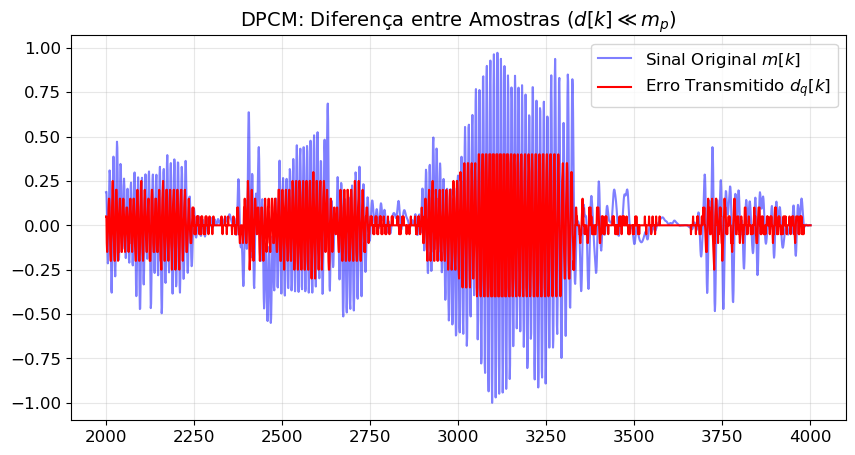

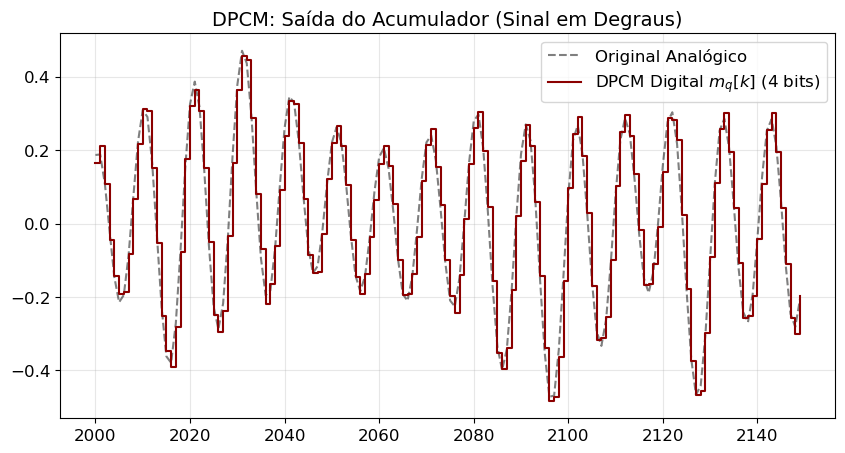

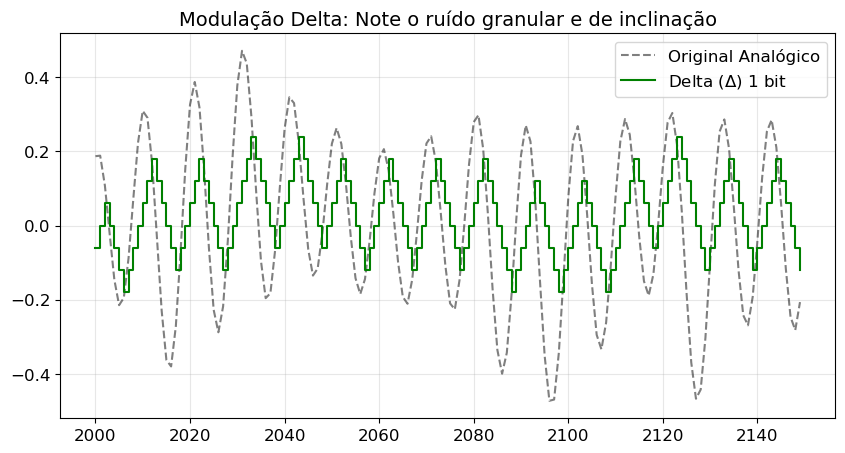

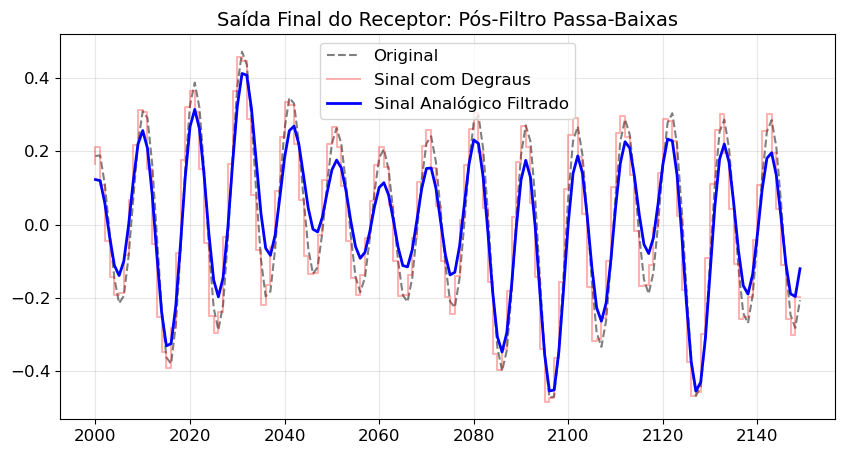

Imagens didáticas prontas para os slides!


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from scipy import signal as sig

# --- Configurações Didáticas ---
plt.rcParams.update({'font.size': 12, 'figure.facecolor': 'white'})

def load_voice_data():
    url = "https://raw.githubusercontent.com/luiz10ml/T27--Digital-Communication/main/Quantizer/VoiceFiltered.dat"
    response = requests.get(url)
    data = np.loadtxt(BytesIO(response.content), skiprows=1)
    return data / np.max(np.abs(data)) # Normalização (Sinal Analógico de entrada)

def uniform_quantizer(val, bits, v_range):
    levels = 2**bits
    step = (2 * v_range) / levels
    # Quantização mid-tread centralizada em 0
    q = np.round(val / step) * step
    return np.clip(q, -v_range, v_range)

# 1. DPCM (Implementação rigorosa do diagrama da pág. 9)
def simulate_dpcm(m, bits, a1=0.98):
    mq = np.zeros(len(m))       # Sinal reconstruído m_q[k]
    dq_trans = np.zeros(len(m)) # Erro quantizado d_q[k]
    m_hat = 0                   # Saída do preditor (estimativa)
    v_range = 0.4               # Faixa menor para o erro d[k]
    
    for k in range(len(m)):
        d = m[k] - m_hat                # Diferença (pág. 9)
        dq = uniform_quantizer(d, bits, v_range)
        mq[k] = dq + m_hat              # Acumulador
        dq_trans[k] = dq
        m_hat = a1 * mq[k]              # Preditor (Atraso + Ganho)
    return mq, dq_trans

# 2. Modulação Delta (Implementação rigorosa do diagrama da pág. 10)
def simulate_delta(m, step_size=0.06):
    mq = np.zeros(len(m))
    m_hat = 0 # Na modulação Delta, m_hat[k] = m_q[k-1]
    
    for k in range(len(m)):
        # Quantizador de 2 níveis (L=2)
        dq = step_size if m[k] > m_hat else -step_size
        mq[k] = m_hat + dq
        m_hat = mq[k] # Acumulador (Atraso Ts)
    return mq

# 3. Filtro de Reconstrução (Demodulador pág. 10)
def low_pass_reconstruction(digital_signal, original):
    b, a = sig.butter(6, 0.2) # Filtro Butterworth de 6ª ordem
    analog = sig.filtfilt(b, a, digital_signal)
    # Correção de escala para compensar atenuação do filtro
    return analog * (np.std(original) / np.std(analog))

# --- Execução Principal ---
m = load_voice_data()
t = np.arange(len(m))
start, end = 2000, 2150 # Janela didática para os gráficos

# Processamento
mq_dpcm, dq_dpcm = simulate_dpcm(m, bits=4)
mq_delta = simulate_delta(m, step_size=0.06)
analog_dpcm = low_pass_reconstruction(mq_dpcm, m)

# --- GERAÇÃO DOS GRÁFICOS ---

# Gráfico 1: Por que DPCM? (A Diferença vs O Sinal) - Ref: Pág 3
plt.figure(figsize=(10, 5))
plt.plot(t[start:end*2], m[start:end*2], label='Sinal Original $m[k]$', color='blue', alpha=0.5)
plt.plot(t[start:end*2], dq_dpcm[start:end*2], label='Erro Transmitido $d_q[k]$', color='red')
plt.title('DPCM: Diferença entre Amostras ($d[k] \ll m_p$)')
plt.legend()
plt.grid(True)
plt.savefig('01_dpcm_diferenca.png', dpi=300)
plt.show()

# Gráfico 2: Modulação DPCM Reconstruída (Digital) - Ref: Pág 9
plt.figure(figsize=(10, 5))
plt.plot(t[start:end], m[start:end], 'k--', alpha=0.5, label='Original Analógico')
plt.step(t[start:end], mq_dpcm[start:end], 'darkred', where='post', label='DPCM Digital $m_q[k]$ (4 bits)')
plt.title('DPCM: Saída do Acumulador (Sinal em Degraus)')
plt.legend()
plt.grid(True)
plt.savefig('02_dpcm_digital.png', dpi=300)
plt.show()

# Gráfico 3: Modulação Delta (Caso Especial) - Ref: Pág 10/11
plt.figure(figsize=(10, 5))
plt.plot(t[start:end], m[start:end], 'k--', alpha=0.5, label='Original Analógico')
plt.step(t[start:end], mq_delta[start:end], 'green', where='post', label='Delta ($\Delta$) 1 bit')
plt.title('Modulação Delta: Note o ruído granular e de inclinação')
plt.legend()
plt.grid(True)
plt.savefig('03_delta_digital.png', dpi=300)
plt.show()

# Gráfico 4: O Papel do Filtro de Reconstrução - Ref: Pág 10 (Demodulador)
plt.figure(figsize=(10, 5))
plt.plot(t[start:end], m[start:end], 'k--', alpha=0.5, label='Original')
plt.step(t[start:end], mq_dpcm[start:end], 'red', alpha=0.3, label='Sinal com Degraus')
plt.plot(t[start:end], analog_dpcm[start:end], 'blue', linewidth=2, label='Sinal Analógico Filtrado')
plt.title('Saída Final do Receptor: Pós-Filtro Passa-Baixas')
plt.legend()
plt.grid(True)
plt.savefig('04_saida_analogica.png', dpi=300)
plt.show()

print("Imagens didáticas prontas para os slides!")